# Step 1 Load Important Modules

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import os
import time
import warnings
import pickle
warnings.filterwarnings('ignore')
print('All Module Loaded Successfully!!')

All Module Loaded Successfully!!


# Step 2: Data Load

In [11]:
data = fetch_california_housing()

In [12]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [13]:
df = pd.DataFrame(data.data,columns = data.feature_names)
df['MedHouseVal'] = data.target

In [14]:
data.target_names

['MedHouseVal']

In [15]:
df.sample(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
5597,1.3333,26.0,2.133929,1.205357,165.0,1.473214,33.80,-118.23,1.875
15937,4.2672,47.0,4.650794,0.971429,1119.0,3.552381,37.72,-122.40,2.194
2701,3.2396,33.0,5.460000,1.076000,825.0,3.300000,32.85,-115.57,0.623
17852,5.3057,26.0,4.596875,1.087500,1089.0,3.403125,37.44,-121.88,2.264
1618,7.6717,26.0,8.128514,1.030120,1486.0,2.983936,37.81,-122.12,4.165


In [17]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [16]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

# Step 3: Exploratory Data Analysis

In [18]:
rows, col = df.shape
print('No of Rows:',rows)
print('No of Cols: ',col)

No of Rows: 20640
No of Cols:  9


In [19]:

df.sample(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
15850,4.5375,23.0,4.600000,1.100000,118.0,2.950000,37.74,-122.44,3.500
13771,4.1361,26.0,5.878195,1.007519,1884.0,2.833083,34.02,-117.03,1.210
1317,5.5000,16.0,6.899103,1.042601,1575.0,3.531390,37.99,-121.80,1.795
6062,6.8758,26.0,6.991228,1.026316,383.0,3.359649,34.00,-117.84,2.538
20528,4.7168,11.0,5.683685,0.997780,2258.0,2.506104,38.55,-121.80,2.232


In [20]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [21]:

df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [22]:

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [23]:
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [24]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [25]:
len(df.columns)

9

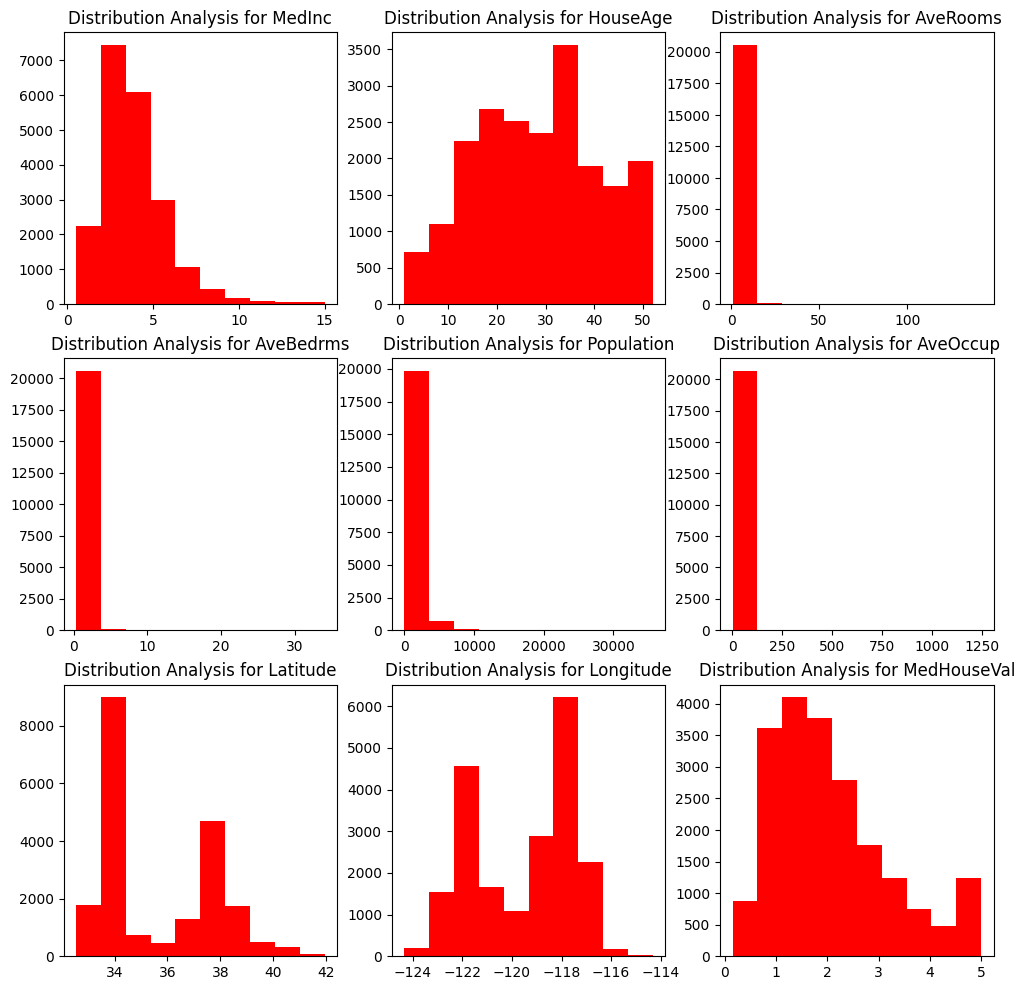

In [16]:

plt.figure(figsize=(12,12))
for i in range(len(df.columns)):
    plt.subplot(3,3,i+1)
    plt.title(f'Distribution Analysis for {df.columns[i]}')
    plt.hist(df[df.columns[i]],color = 'r')

plt.show()

<Axes: title={'center': 'Correlation b/w Features '}>

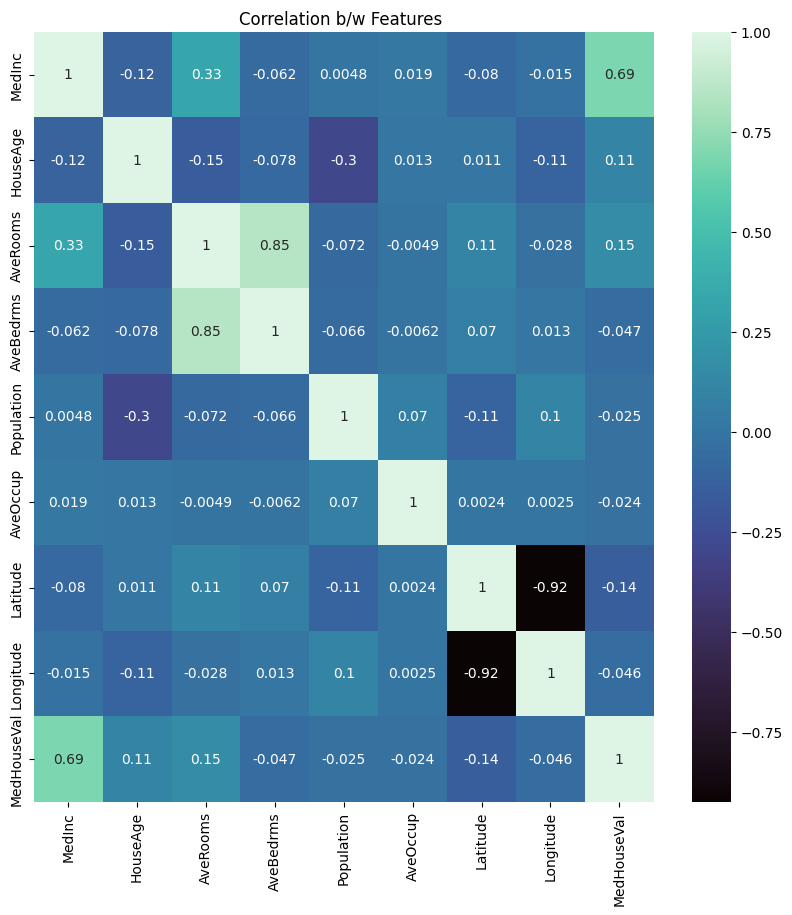

In [26]:
plt.figure(figsize=(10,10))
plt.title('Correlation b/w Features ')
sns.heatmap(df.corr(),annot = True,cmap='mako')

In [59]:
compare_df = pd.DataFrame({
    "Actual Price": y_test, # type: ignore
    "Predicted Price": y_pred # type: ignore
})

compare_df.head(10)

,Actual Price,Predicted Price
3919,2.403,2.311056
6180,2.070,1.884173
6265,1.635,2.076499
12891,1.079,1.570659
12792,0.926,1.552453
6148,1.439,1.720335
634,1.910,2.259557
18178,3.370,1.994439
9728,2.451,2.033601
11998,1.643,0.648281


In [61]:
from sklearn.metrics import r2_score

# Use existing predictions from compare_df
y_test_eval = compare_df["Actual Price"]
y_pred_eval = compare_df["Predicted Price"]

mae = mean_absolute_error(y_test_eval, y_pred_eval)
mse = mean_squared_error(y_test_eval, y_pred_eval)
rmse = root_mean_squared_error(y_test_eval, y_pred_eval)
r2 = r2_score(y_test_eval, y_pred_eval)

print("=" * 40)
print("Model Evaluation")
print("=" * 40)
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")

Model Evaluation
MAE      : 0.5730
MSE      : 0.6126
RMSE     : 0.7827
R² Score : 0.5433


# Step 4 Data Preprocessing

In [27]:

X = df.iloc[:, :-2]
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85
...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43


In [28]:

y = df['MedHouseVal']

In [29]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [30]:
scaler = MinMaxScaler()

In [31]:
scaled_X = scaler.fit_transform(X)

In [32]:
scaled_df = pd.DataFrame(scaled_X,columns=X.columns)

In [33]:
scaled_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude
0,0.539668,0.784314,0.043512,0.020469,0.008941,0.001499,0.567481
1,0.538027,0.392157,0.038224,0.018929,0.067210,0.001141,0.565356
2,0.466028,1.000000,0.052756,0.021940,0.013818,0.001698,0.564293
3,0.354699,1.000000,0.035241,0.021929,0.015555,0.001493,0.564293
4,0.230776,1.000000,0.038534,0.022166,0.015752,0.001198,0.564293
...,...,...,...,...,...,...,...
20635,0.073130,0.470588,0.029769,0.023715,0.023599,0.001503,0.737513
20636,0.141853,0.333333,0.037344,0.029124,0.009894,0.001956,0.738576
20637,0.082764,0.313725,0.030904,0.023323,0.028140,0.001314,0.732200
20638,0.094295,0.333333,0.031783,0.024859,0.020684,0.001152,0.732200


In [34]:
scaled_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,0.232464,0.541951,0.032488,0.022629,0.039869,0.001914,0.328572
std,0.131020,0.246776,0.017539,0.014049,0.031740,0.008358,0.226988
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142308,0.333333,0.025482,0.019943,0.021974,0.001398,0.147715
50%,0.209301,0.549020,0.031071,0.021209,0.032596,0.001711,0.182784
75%,0.292641,0.705882,0.036907,0.022713,0.048264,0.002084,0.549416
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



# Step 5: Train Test Part Data Divide

In [35]:
X_train, X_test, y_train, y_test = train_test_split(scaled_X,y,test_size=0.1, random_state=32)

In [36]:
X_train.shape

(18576, 7)

In [37]:
X_test.shape

(2064, 7)

In [38]:
y_train.shape

(18576,)

In [39]:
y_test.shape

(2064,)

# Step 6: Model Building ML

In [40]:
model = LinearRegression()

In [41]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred = model.predict(X_test)

In [43]:
compare_df = pd.DataFrame({'Actual Y': y_test, 'Predicted Y':y_pred})

In [44]:
compare_df

,Actual Y,Predicted Y
20038,0.52300,0.830969
17684,0.87500,1.171607
9720,2.53800,2.014867
17295,5.00001,4.142535
18736,0.98100,1.535928
...,...,...
12779,0.49800,0.990029
12771,0.67000,1.130043
15974,2.41900,2.563409
5100,1.42600,2.243695



# Step 7: Model Evaluation

In [45]:
score = model.score(X_test,y_test)
print('Model Score: ',score)

Model Score:  0.551362762499376


In [46]:

mae = mean_absolute_error(y_test,y_pred)
print('Mean Absolute Error',mae)

Mean Absolute Error 0.5677843233572074


In [47]:
mse = mean_squared_error(y_test,y_pred)
print('Mean Sqaured Error',mse)

Mean Sqaured Error 0.6052385210505213


In [48]:
rmse = root_mean_squared_error(y_test,y_pred)
print('Root Mean Sqaured Error',rmse)

Root Mean Sqaured Error 0.7779707713343229



# Step 8: Final Model Checking

In [49]:
matrix_dict = {'Model Number':[],'Model':[],'Model Score':[],'MAE':[],'MSE':[],'RMSE':[]}

for i in range(5000):
    X_train, X_test, y_train, y_test = train_test_split(scaled_X,y,test_size=0.1, random_state=i)
    model = LinearRegression()
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    score = model.score(X_test,y_test)
    mae = mean_absolute_error(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)
    rmse = root_mean_squared_error(y_test,y_pred)

    matrix_dict['Model Number'].append(i)
    matrix_dict['Model'].append(model)
    matrix_dict['Model Score'].append(score)
    matrix_dict['MAE'].append(mae)
    matrix_dict['MSE'].append(mse)
    matrix_dict['RMSE'].append(rmse)
    print(f'Checking Model {i+1}')
    display(clear= True)

matrix_df = pd.DataFrame(matrix_dict)
print('Done')

Done


In [50]:
matrix_df

,Model Number,Model,Model Score,MAE,MSE,RMSE
0,0,LinearRegression(),0.539876,0.584250,0.632354,0.795207
1,1,LinearRegression(),0.539413,0.574266,0.619368,0.786999
2,2,LinearRegression(),0.502733,0.589630,0.668455,0.817591
3,3,LinearRegression(),0.568915,0.563485,0.580866,0.762146
4,4,LinearRegression(),0.533087,0.573290,0.587384,0.766410
...,...,...,...,...,...,...
4995,4995,LinearRegression(),0.500881,0.574729,0.642570,0.801605
4996,4996,LinearRegression(),0.500247,0.576966,0.693597,0.832825
4997,4997,LinearRegression(),0.505985,0.576654,0.662073,0.813678
4998,4998,LinearRegression(),0.517502,0.568705,0.611983,0.782293


In [51]:
matrix_df['Model Score'].max()

np.float64(0.6053940148587416)

In [52]:
matrix_df['Model Score'].min()

np.float64(-17.62796671892976)

In [53]:
final_model_df = matrix_df[matrix_df['Model Score'] == matrix_df['Model Score'].max()]

In [54]:
matrix_positive_df = matrix_df[matrix_df['Model Score']>=0.50]

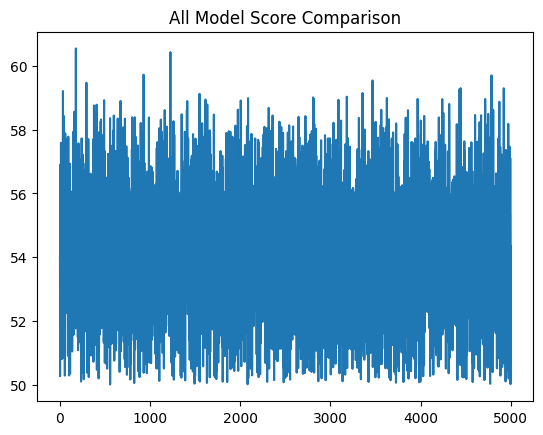

In [55]:
plt.plot(matrix_positive_df['Model Number'], matrix_positive_df['Model Score']*100)
plt.title('All Model Score Comparison')
plt.show()

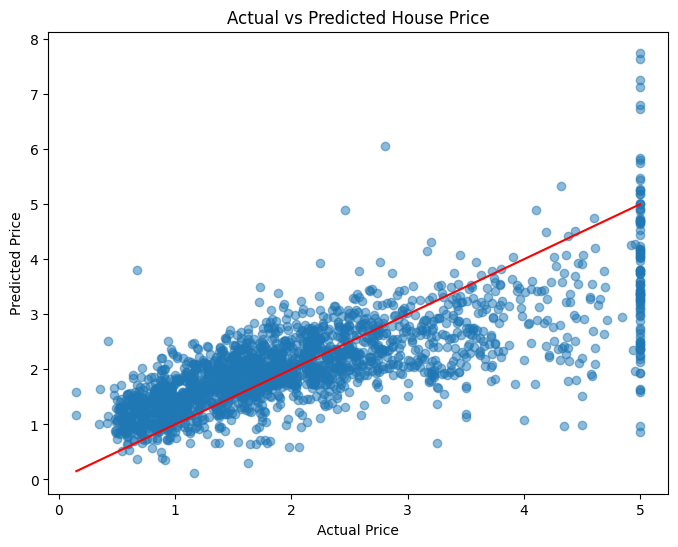

In [62]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Price")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

Residual Plot

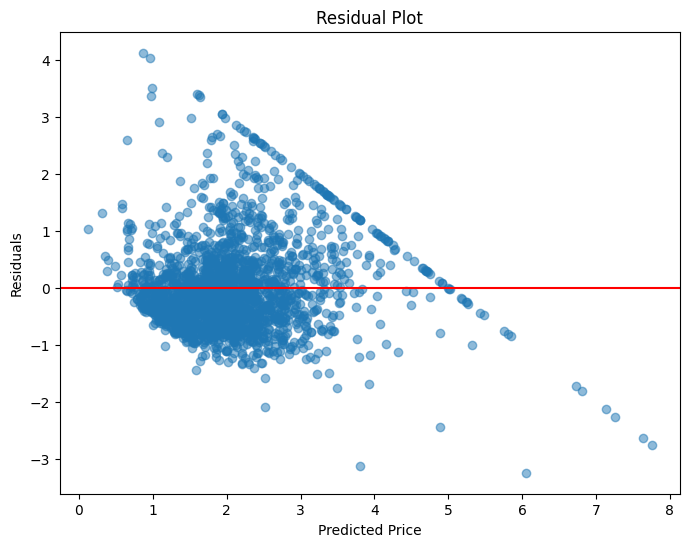

In [63]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0,color='red')

plt.xlabel("Predicted Price")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [66]:
housing_df = pd.DataFrame(data.data, columns=data.feature_names)
housing_df["Price"] = data.target

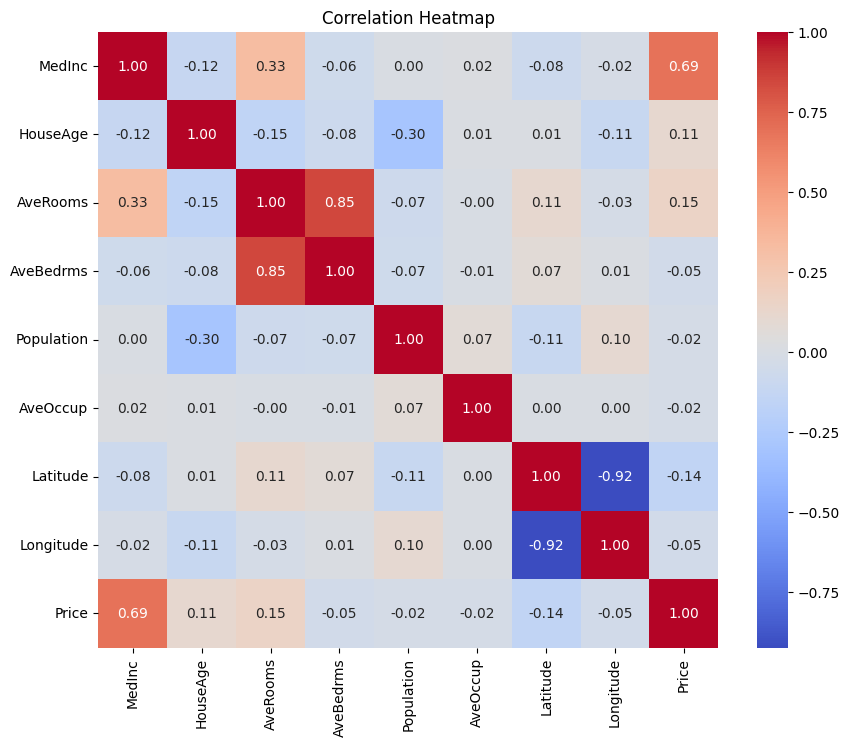

In [67]:
plt.figure(figsize=(10,8))

sns.heatmap(
    housing_df.corr(), # type: ignore
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

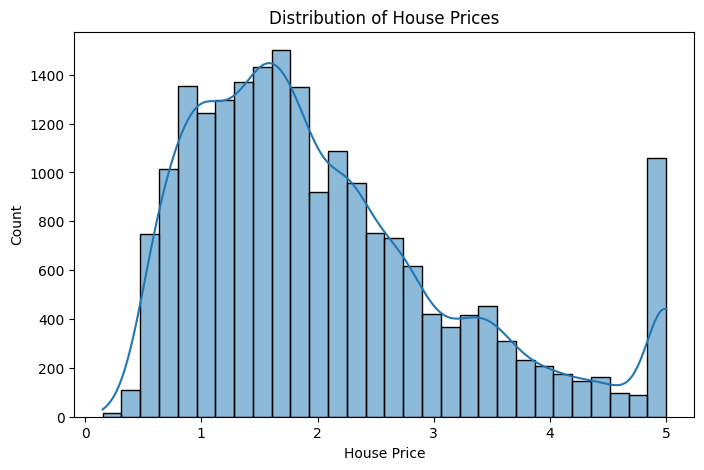

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(y, bins=30, kde=True)

plt.title("Distribution of House Prices")

plt.xlabel("House Price")

plt.show()

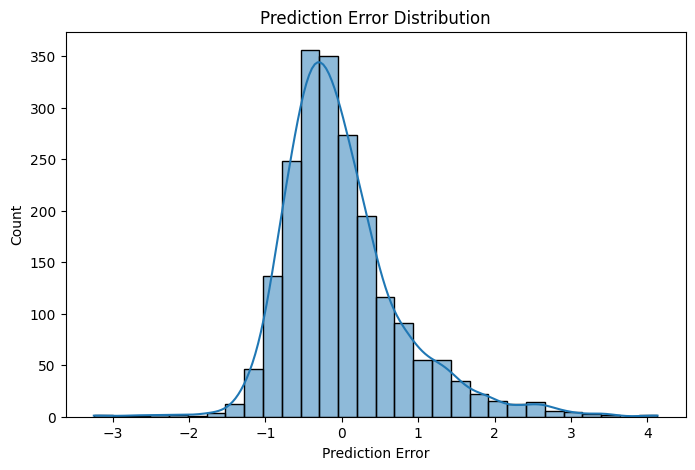

In [69]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(errors, bins=30, kde=True)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")

plt.show()


# Step 9: Final Model Save

In [56]:
final_model = final_model_df['Model']

In [57]:

final_model.values[0]

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [73]:
import pickle

with open("housing_model.pkl", "wb") as f:
    pickle.dump(model, f)
print('Model Saved Successfully!!!')    

Model Saved Successfully!!!


# Done